<Axes: >

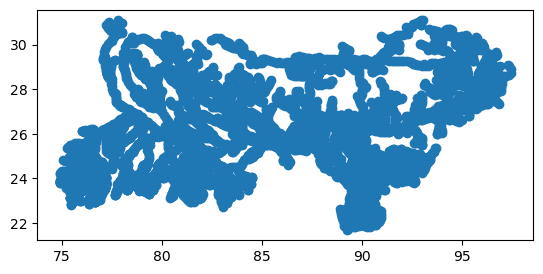

In [2]:
import geopandas as gpd#shapefile read 
gbmdf_op= gpd.read_file(r"/Users/sharm/Documents/SWOT/GBM_points.shp")
gbmdf_op = gbmdf_op.drop(columns=['records'])
# print(gbmdf_op)
gbmdf_op.plot()

In [3]:
import os
import dask
import dask.dataframe as dd
from dask.distributed import Client

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import requests

import datetime
from io import StringIO
FTS_URL = "https://fts.podaac.earthdata.nasa.gov/v1"  
HYDROCRON_URL = "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries"

def query_hydrocron(query_url, reach_id, start_time, end_time, fields, empty_df):
    """Query Hydrocron for reach-level time series data.

    Parameters
    ----------
    query_url: str - URL to use to query FTS
    reach_id: str - String SWORD reach identifier
    start_time: str - String time to start query
    end_time: str - String time to end query
    fields: list - List of fields to return in query response
    empty_df: pandas.DataFrame that contains empty query results

    Returns
    -------
    pandas.DataFrame that contains query results
    """

    params = {
        "feature": "Reach",
        "feature_id": reach_id,
        "output": "csv",
        "start_time": start_time,
        "end_time": end_time,
        "fields": fields,
        "collection_name": "SWOT_L2_HR_RiverSP_D"
    }
    results = requests.get(query_url, params=params)
    if "results" in results.json().keys():
        results_csv = results.json()["results"]["csv"]
        df = pd.read_csv(StringIO(results_csv))
    else:
        df = empty_df

    return df

In [4]:
gbm_file_op=pd.read_csv(r"/Users/sharm/Documents/SWOT/GBM_points.csv")
gbm_file_op['reach_id']
ids=gbm_file_op['reach_id']
ids 

0       45220200994
1       45220200131
2       45220200144
3       45220200151
4       45220201061
           ...     
7052    45249900536
7053    45230000371
7054    45230000381
7055    45311301135
7056    45220600216
Name: reach_id, Length: 7057, dtype: int64

In [ ]:
# Create queries that return Pandas.DataFrame objects
start_time = "2023-01-01T00:00:00Z"
end_time = "2025-10-27T00:00:00Z"
fields = "reach_id,time_str,wse"

for reach in ids:
    pathname = r"/Users/sharm/Documents/SWOT/GBM_D/"+str(reach)+'.csv'#condition not to download the same files
    if os.path.exists(pathname) == False:
        # Create an empty dataframe for cases where no data is returned for a reach identifier
        empty_df = pd.DataFrame({
            "reach_id": np.int64(reach),
            "time_str": datetime.datetime(1900, 1, 1).strftime("%Y-%m-%dT%H:%M:%S"),
            "wse": -99.0,
            "wse_units": "m"
        }, index=[0])
        results = query_hydrocron(HYDROCRON_URL, reach, start_time, end_time, fields, empty_df)

   
        ddf = results.loc[(results["wse"] != -999999999999.0)]

        # # Convert time_str to datetime format
        ddf.time_str = pd.to_datetime(ddf.time_str)
        ddf['Date'] = ddf.time_str
        ddf.set_index('Date', inplace=True)
        ddf1=ddf.drop(['time_str'],axis=1)
#         ddf1.to_csv(r"/Users/sharm/Documents/SWOT/GBM_D/"+str(reach)+'.csv')
        ddf1.to_csv(pathname) #downloading csv file for reach_id using ids loop

In [8]:
# Define paths
folder_2_0 = "/Users/sharm/Documents/SWOT/GBM_2.0"
folder_D = "/Users/sharm/Documents/SWOT/GBM_D"
output_folder = "/Users/sharm/Documents/SWOT/swot_wse"

os.makedirs(output_folder, exist_ok=True)

def merge_gbm_data(folder_2_0, folder_D, output_folder):
    for file in os.listdir(folder_2_0):
        if file.endswith('.csv') and os.path.exists(os.path.join(folder_D, file)):
            df_2_0 = pd.read_csv(os.path.join(folder_2_0, file))
            df_D = pd.read_csv(os.path.join(folder_D, file))

            # Parse and clean dates
            for df in [df_2_0, df_D]:
                if 'Date' in df.columns:
                    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
                elif 'time_str' in df.columns:
                    df['Date'] = pd.to_datetime(df['time_str']).dt.tz_localize(None)

            # Merge on reach_id + Date
            merged = pd.merge(df_2_0, df_D, on=['reach_id', 'Date'], how='outer', suffixes=('_2.0', '_D'))

            # Merge wse values
            merged['wse'] = merged.get('wse_2.0').combine_first(merged.get('wse_D'))

            # Handle wse_units
            if 'wse_units_2.0' in merged.columns or 'wse_units_D' in merged.columns:
                merged['wse_units'] = merged.get('wse_units_2.0').combine_first(merged.get('wse_units_D'))
            else:
                merged['wse_units'] = "m"  # Default fallback

            # Drop old suffix columns
            drop_cols = [col for col in merged.columns if 'wse_' in col or 'time_str' in col]
            merged.drop(columns=drop_cols, inplace=True, errors='ignore')

            # Reorder columns safely
            base_cols = ['reach_id', 'Date', 'wse']
            if 'wse_units' in merged.columns:
                base_cols.append('wse_units')
            other_cols = [col for col in merged.columns if col not in base_cols]
            merged = merged[base_cols + other_cols]

            # Sort by date
            merged.sort_values(by='Date', inplace=True)

            # Save
            output_path = os.path.join(output_folder, file)
            merged.to_csv(output_path, index=False)

# Run the function
merge_gbm_data(folder_2_0, folder_D, output_folder)


In [9]:
recordgbmdf_op=pd.DataFrame(columns=['reach_id','records'])#creating dataframe
gbm_file_op=pd.read_csv(r"/Users/sharm/Documents/SWOT/GBM_points.csv")
ids=gbm_file_op['reach_id']
for reach in ids:
    gbm_df_op = pd.read_csv('/Users/sharm/Documents/SWOT/GBM/'+str(reach)+'.csv')
    recordgbmdf_op.loc[len(recordgbmdf_op)]=[reach,gbm_df_op.shape[0]-1]
    print(reach,gbm_df_op.shape[0]-1)#Counting gbm  
print("Total reach_id processed:", len(recordgbmdf_op))

45220200994 0
45220200131 15
45220200144 0
45220200151 10
45220201061 31
45220201091 32
45220201121 32
45220201141 25
45220201151 25
45220201081 20
45220201171 25
45253002061 25
45220200344 0
45220200121 15
45220201011 15
45220201021 15
45220201041 32
45220201071 31
45220201111 32
45220201131 32
45253002015 24
45220200885 16
45220200855 16
45230000365 16
45253002005 23
45220200455 15
45220200465 15
45220200475 15
45220200485 15
45220200495 14
45220200505 15
45220200515 15
45220200525 15
45220200535 71
45220200245 13
45220200895 15
45220200845 43
45220200775 57
45220200045 9
45220200051 13
45220200061 14
45220200071 15
45220200081 14
45220200091 15
45220200101 15
45220200111 15
45220200715 67
45220200965 65
45220200935 78
45220200635 63
45220200665 49
45220200795 60
45220200785 54
45220200765 56
45220200735 61
45220200725 70
45220200295 15
45220200985 69
45220200915 24
45220200875 16
45253002025 16
45220200305 16
45220200745 64
45220200025 13
45220200035 10
45220200545 64
45220200595 69

45241700021 68
45241700031 64
45241700041 68
45241800011 70
45241800021 103
45241800031 103
45241800041 104
45241800051 103
45241800061 97
45241800071 103
45241800081 102
45241800091 67
45241601351 16
45241800111 71
45241601366 0
45241800126 0
45241900021 121
45241900041 110
45241900051 110
45241900061 102
45241900071 25
45241900081 102
45241900094 0
45241900101 25
45241900111 98
45241900124 0
45241900131 25
45242100011 69
45242100021 68
45242100031 67
45242100041 65
45242100051 17
45242100071 63
45242100081 61
45242100094 46
45242100131 62
45242100141 68
45242100101 65
45242100111 69
45242100121 59
45242100611 95
45242100621 94
45242100181 57
45242100481 61
45242100494 -1
45242100711 17
45242100151 65
45242100171 59
45242100501 69
45242100191 16
45242100301 42
45242100311 42
45242100321 54
45242100331 56
45242100341 61
45242100351 61
45242100361 61
45242100201 63
45242100211 64
45242100221 92
45242100231 62
45242100241 61
45242100251 67
45242100261 60
45242100271 34
45242100604 0
4524

45244100101 72
45244100111 42
45244100081 92
45244100121 80
45244100131 20
45244100151 61
45244100161 24
45244100171 105
45244100181 105
45244100191 101
45244100201 84
45244100211 92
45244100221 96
45244100231 72
45244100241 71
45244100251 71
45244100261 70
45244100271 67
45244100281 72
45244100291 72
45244100301 73
45244100311 69
45244100321 68
45244100331 78
45244100341 19
45244100351 18
45244100361 94
45243601756 0
45244100376 0
45244200021 69
45244200031 71
45244200041 70
45244201261 73
45244201251 73
45244201271 76
45244201281 25
45244200061 71
45244200071 95
45244200081 72
45244200091 72
45244200101 79
45244200111 76
45244200121 101
45244201171 108
45244201181 79
45244201191 78
45244201201 81
45244201211 69
45244201221 16
45244201231 13
45244200141 103
45244200151 101
45244200161 98
45244200171 100
45244200181 98
45244200191 65
45244200201 68
45244200211 66
45244200231 76
45244200241 70
45244200251 69
45244200261 166
45244200271 167
45244200281 162
45244200291 159
45244200301 107

45254000336 0
45254001036 0
45254000756 0
45254000966 0
45255001061 72
45255000051 20
45255001151 82
45255001241 70
45255001231 69
45255000081 23
45255000091 97
45255000101 69
45255000111 68
45255000121 15
45255000131 96
45255000591 81
45255000601 69
45255000501 15
45255000511 15
45255000521 15
45255000534 0
45255000541 69
45255000551 72
45255000561 72
45255000571 96
45255000151 59
45255000161 67
45255000171 62
45255000191 50
45255000201 17
45255000211 66
45255000291 53
45255000301 51
45255000311 48
45255000381 15
45255000391 15
45255001291 76
45255001211 15
45255001201 64
45254001271 11
45254001261 15
45255000401 77
45255000411 64
45255000421 93
45255000431 15
45255000441 20
45257000341 79
45255000451 22
45255000461 21
45255000471 18
45255000481 68
45255000221 69
45255000241 15
45255000251 67
45255000071 23
45255000061 76
45255001071 77
45255001081 88
45255001101 15
45255000681 51
45255000691 95
45255001161 22
45255001191 72
45255001181 76
45255000711 105
45255000721 78
45255000731 77

45280500231 16
45280500311 16
45280500461 73
45280500441 49
45280500361 65
45280500481 0
45280500301 38
45280500406 0
45280500176 0
45280500246 0
45280500326 0
45280500476 0
45280500376 0
45280500496 0
45280500111 16
45280600011 13
45280600021 45
45280600121 8
45280600131 16
45280600031 -1
45280600091 27
45280600101 44
45280600051 46
45280600061 7
45280600146 0
45280600116 0
45280600076 0
45280700011 62
45280700031 41
45280700041 45
45280700061 7
45280700071 62
45280700091 75
45280700101 43
45280700111 14
45280700161 8
45280700171 0
45280700081 60
45280700141 29
45280700186 0
45280700156 0
45280800011 37
45280800021 63
45280800031 75
45280800041 38
45280800051 37
45280800061 26
45280800071 25
45280800084 -1
45280800091 18
45280800101 24
45280800111 2
45280800171 65
45280800201 8
45280800211 8
45280800121 36
45280800131 38
45280800141 45
45280800186 0
45280800226 0
45280800156 0
45280900011 37
45280900021 72
45280900031 72
45280900041 67
45280900051 75
45280900061 75
45280900071 74
4528

45243601831 71
45243601841 75
45243601471 66
45243601481 93
45243601491 92
45243803671 168
45243803681 157
45243803691 249
45243803701 164
45253001741 17
45270000941 72
45280200291 14
45280200301 16
45280200111 45
45280200121 45
45280200131 45
45280200141 16
45280200151 46
45280200161 47
45280200171 61
45280200181 69
45280200371 16
45280200381 12
45280200391 0
45280200191 74
45280200201 68
45280200211 69
45280200221 63
45280200231 56
45280200241 12
45280200251 16
45280200261 0
45280200271 11
45280200551 3
45280200281 16
45280200041 71
45280200081 45
45280200091 45
45280200101 44
45280200051 67
45280200061 45
45280200071 45
45280300111 16
45280300121 7
45280500331 56
45280700121 5
45220200815 72
45220300135 66
45241100075 69
45243600261 69
45243601351 66
45243801811 167
45253001881 17
45253001751 16
45253000015 24
45253001641 17
45254001341 8
45257000381 23
45270000021 80
45270000451 94
45280100021 23
45280200771 16
45280200741 16
45280300171 14
45280500261 15
45280700051 33
45291000011

45244700111 24
45244700126 0
45244800011 67
45244800021 68
45244800031 67
45244800041 67
45244800054 -1
45244800061 102
45244800071 70
45244800081 71
45244800091 71
45244800101 70
45244800111 101
45244800121 65
45244800131 68
45244800141 68
45244800151 68
45244800166 0
45244900011 68
45244900021 67
45244900031 67
45244900041 257
45244900051 252
45244900061 256
45244900071 253
45244900081 256
45244900091 255
45244900101 258
45244900111 257
45244900341 114
45244900361 114
45244900131 259
45244900141 256
45244900151 241
45244900161 231
45244900171 245
45244900181 250
45244900191 161
45244900201 117
45244900211 178
45244900221 254
45244900241 248
45244900251 251
45244900261 257
45244900271 258
45244900376 0
45244900286 0
45245600741 156
45245600751 155
45245600761 16
45245600771 82
45245600781 95
45245600241 244
45245600791 93
45245600801 90
45245600811 91
45245600821 88
45245600831 90
45245600841 72
45245600851 86
45245600861 91
45245600871 89
45245600881 92
45245600891 92
45245600251 245

45247200741 15
45247200754 0
45247200761 69
45247200774 -1
45247200781 72
45247202401 58
45247202414 -1
45247202421 69
45247202434 -1
45247202441 54
45247202454 -1
45247202461 52
45247202474 21
45247202481 12
45247202504 -1
45247200794 -1
45247200801 67
45247200814 -1
45247200821 64
45247200834 0
45247200841 16
45247200854 0
45247200861 73
45247200874 53
45247200883 16
45247200901 68
45247201714 0
45247201721 78
45247201734 -1
45247201741 58
45247201994 -1
45247202001 18
45247202014 9
45247202024 -1
45247202031 50
45247202044 36
45247202051 16
45247202064 0
45247202081 52
45247201754 -1
45247201761 52
45247201774 9
45247201784 0
45247201791 15
45247201804 0
45247201811 15
45247201824 0
45247201831 11
45247201844 9
45247201854 -1
45247202211 16
45247202234 11
45247201861 42
45247201874 -1
45247201881 58
45247201894 13
45247201904 0
45247201911 14
45247201924 4
45247201944 0
45247202886 0
45247202926 0
45247202566 0
45247202846 0
45247202806 0
45247201336 0
45247201246 0
45247202716 0
45

45248500011 103
45248500021 103
45248500031 68
45248500041 68
45248600011 68
45248600021 102
45248600031 102
45248600041 66
45248600051 66
45248600061 65
45248600071 66
45248600081 66
45248600091 61
45248600101 65
45248600111 61
45248600121 63
45248600131 64
45248600143 64
45248600161 66
45248600211 56
45248600221 57
45248600231 53
45248600241 39
45248600251 48
45248600261 9
45248600281 11
45248600301 9
45248600311 7
45248600331 9
45248600193 15
45248600176 0
45248600296 0
45248600346 0
45248600206 0
45248700011 71
45248800011 71
45248800021 76
45248800031 104
45248800041 103
45248800051 66
45248800061 139
45248800071 136
45248800811 15
45248800821 55
45248800831 15
45248800841 21
45248800853 15
45248800861 18
45248802781 15
45248802791 15
45248802803 15
45248800081 67
45248800093 16
45248800103 16
45248800111 91
45248800123 67
45248800131 78
45248800143 16
45248800153 16
45248800163 67
45248800171 71
45248800183 72
45248800191 16
45248800871 72
45248800883 23
45248800891 54
4524880090

45249900361 71
45249900526 0
45249900486 0
45249900446 0
45249900356 0
45311100081 72
45311100825 16
45311101075 69
45311101335 101
45311101515 57
45311100105 80
45311101605 68
45311101715 15
45311101325 97
45311101315 16
45311101305 73
45311101295 70
45311101285 68
45311101275 62
45311100555 54
45311101615 69
45311101705 24
45311101655 98
45311101765 24
45311101805 19
45311101815 15
45311101825 16
45311101835 15
45311101845 14
45311101855 60
45311101865 15
45311101885 15
45311101895 16
45311101905 16
45311101175 100
45311100215 74
45311100205 66
45311100195 71
45311100185 57
45311100175 91
45311100915 77
45311100905 67
45311100895 78
45311100945 78
45311100935 23
45311100925 74
45311101025 56
45311101035 82
45311101015 74
45311101005 79
45311100955 78
45311100665 100
45311100655 100
45311100645 15
45311101425 70
45311100585 77
45311101445 87
45311100575 54
45311101505 86
45311101595 99
45311100695 61
45311101695 15
45311101725 15
45311100155 16
45311100775 70
45311101435 58
4531110179

In [10]:
print(recordgbmdf_op)

         reach_id  records
0     45220200994        0
1     45220200131       15
2     45220200144        0
3     45220200151       10
4     45220201061       31
...           ...      ...
7052  45249900536        0
7053  45230000371        0
7054  45230000381        0
7055  45311301135        0
7056  45220600216        0

[7057 rows x 2 columns]


In [11]:
merged_gdfgbm_op = gbmdf_op.merge(recordgbmdf_op, on='reach_id', how='left')
merged_gdfgbm_op.to_file(r"/Users/sharm/Documents/SWOT/Geojson/records_points.geojson", driver="GeoJSON")#record save gbm